In [1]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import time
import matplotlib.pyplot as plt
import itertools as it
from mpl_toolkits.mplot3d import Axes3D
from IPython.core.display import HTML


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [2]:
plot ='gauss'
colors = True
transparent = False

x_0 = 0.
x_1 = 0.5
if (plot == 'gauss'):
    nh_min = 256
    locs = []
    epsilons = [1]
    mus = [1]
else:
    nh_min = 64
    locs = [x_1]
    epsilons = [0.5, 1]
    mus = [0.5, 1]

In [3]:

refRatio = 2
CFL = np.sqrt(0.5)
nt = 20

Hans = False

deriv = 'CD'
RK = 4
order = 2

L = 1.

In [4]:
omega = BT.Grid(nh_min)
physics = BT.PhysProps(omega, epsilons, mus, locs = locs)

xCell = omega.xCell
xNode = omega.xNode
cs = physics.cs

In [5]:
t_f = 0.4
t = np.linspace(0, t_f, num = nh_min + 1)

In [6]:
if (locs != []):
    vecs = [[0, 0, 0, 1], [0, 0, 0, -1], [0, 0, 1.8, 0]]
    X, Y, DX, DY = zip(*vecs)
    fig, ax = plt.subplots(figsize = [6, 6])
    plt.xlim(-0.05, 0.5)
    plt.ylim(-1.25, 1.25)
    
    ax.quiver(X, Y, DX, DY, color = 'k', scale = 2.25, zorder = 2)#, arrow_length_ratio = 0.075)
    for x_f in (xNode[::4]):
        x_1 = x_f - (cs[1] * t_f)
        x_c2 = (cs[1] * t) + x_1
        x_c2[x_c2 <= locs[0]] = 0
        x_0 = (((cs[1] - cs[0]) * locs[0]) + (cs[0] * x_1)) / cs[1]
        x_c1 = (cs[0] * t) + x_0
        x_c1[x_c1 > locs[0]] = 0
        x = np.asarray(x_c1) + np.asarray(x_c2)
        if ((x > locs[0]).all()):
            color = PT.ColorDefault(0)
        else:
            if ((x <= locs[0]).all()):
                color = PT.ColorDefault(2)
            else:
                color = PT.ColorDefault(9)
        if (x[-1] > 0):
            if (colors):
                plt.plot(t, x, color = color, zorder = 1)
            else:
                plt.plot(t, x, color = PT.ColorDefault(0), zorder = 1)
            # plt.text(1.01 * t_f, x[-1], r'$x$')
            print(x[-1])
    t_s = np.asarray([0, t_f])
    x_s = locs[0] * np.ones(2, float)
    x_top = np.ones(2, float)
    t_fl = t_f * np.ones(2, float)
    x_tf = np.asarray([0, 1])
    
    plt.plot(t_s, x_s, color = PT.ColorDefault(3), linestyle = '--', zorder = 0)
    plt.plot(t_s, x_top, color = PT.ColorDefault(3), linestyle = '--', zorder = 0)
    plt.plot(t_fl, x_tf, color = PT.ColorDefault(3), linestyle = '--', zorder = 0)
    plt.text(-0.03, locs[0], r'$x_{s}$')#, color = PT.ColorDefault(3))
    plt.text(-0.02, 0.95, '1')#, color = PT.ColorDefault(3))
    plt.text(0.41, 0.25, r'$\frac{\mathrm{d} x}{\mathrm{d} t} = c_{1}$')
    plt.text(0.41, 0.75, r'$\frac{\mathrm{d} x}{\mathrm{d} t} = c_{2}$')
    plt.text(t_f, -0.125, r'$t$')#, color = PT.ColorDefault(3))
    plt.text(1.11 * t_f, -0.025, r'$t$')
    plt.text(-0.01, 1.175, r'$x$')
    plt.axis('off')
    plt.show()
    saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/MultMedCharLines' # + appendage
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = transparent)
    

[20, 43, 64, 85, 107]
[2.99742125e-07 4.67383234e-07 7.23702849e-07 1.11277982e-06 1.69910416e-06 2.57627710e-06 3.87906403e-06 5.79993504e-06 8.61154580e-06 1.26969938e-05 1.85901333e-05 2.70287466e-05 3.90239400e-05 5.59497473e-05 7.96575507e-05 1.12620532e-04 1.58113883e-04 2.20436872e-04 3.05182961e-04 4.19563915e-04 5.72793106e-04 7.76531791e-04 1.04540002e-03 1.39755071e-03 1.85530130e-03 2.44581233e-03 3.20179569e-03 4.16222839e-03 5.37303914e-03 6.88772671e-03 8.76786018e-03 1.10834031e-02 1.39127970e-02 1.73427344e-02 2.14675511e-02 2.63881680e-02 3.22105234e-02 3.90434449e-02 4.69959337e-02 5.61738565e-02 6.66760716e-02 7.85900516e-02 9.19871045e-02 1.06917336e-01 1.23404534e-01 1.41441192e-01 1.60983922e-01 1.81949517e-01 2.04211933e-01 2.27600457e-01 2.51899293e-01 2.76848754e-01 3.02148195e-01 3.27460741e-01 3.52419785e-01 3.76637128e-01 3.99712548e-01 4.21244497e-01 4.40841533e-01 4.58134053e-01 4.72785827e-01 4.84504851e-01 4.93053011e-01 4.98254130e-01 5.00000000e-01 4.

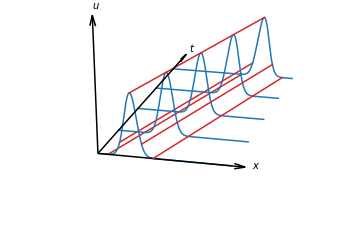

In [7]:
if (locs == []):
    t_f = 1.
    t_snaps = 5
    sigma, mu = WFT.GaussParams(x_0, x_1)
    sigma = 1.5 * sigma
    t_f = (1. - (2. * mu)) / cs[0]
    vecs = [0, 0, 1]
    args = [sigma, mu]
    
    vecs = np.array([[0, 0, 0, 1.1, 0, 0], [0, 0, 0, 0, 0.6, 0], [0, 0, 0, 0, 0, 1.05]])
    X, Y, Z, DX, DY, DZ = zip(*vecs)
    
    #waveInit = WFT.InitCond(omega, physics, WFT.Gauss, args)#, cellAve = False)
    t = np.zeros(nh_min + 1)
    js = [((nh_min / 4) - 2) / 3, ((nh_min / 2) + 1) / 3, nh_min / 4, (nh_min - 1) / 3, (((5 * nh_min) / 4) + 2) / 3]# nh_min / 2]#, ((2 * nh_min) + 1) / 3]#, (((5 * nh_min) / 2) + 2) / 3]
    js = [int(j) for j in js]
    print(js)
    # fig, ax = plt.subplots()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection = '3d')
    ax.view_init(30, 285)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$t$')
    ax.set_zlabel(r'$u$')
    ax.axis('off')
    ax.quiver(X, Y, Z, DX, DY, DZ, color = 'k', arrow_length_ratio = 0.075)
    ax.text(1.15, 0, 0, r'$x$')
    ax.text(0, 0.625, 0, r'$t$')
    ax.text(0, 0, 1.1, r'$u$')
    ts = np.zeros((2, t_snaps), float)
    xs = np.zeros((2, t_snaps), float)
    us = np.zeros((2, t_snaps), float)
    ax.set_xlim(-0.1, 1.2)
    ax.set_ylim(-0.1, 0.21)
    ax.set_zlim(-0.1, 0.7)
    
    for i in range(t_snaps):
        t_val = (i * t_f) / (t_snaps - 1)
        t = t_val * np.ones(nh_min + 1)
        waveProp = 0.5 * WFT.Advect(omega, physics, WFT.Gauss, args, t_val, cellAve = False, field = 'E')
        if (i == 0):
            ts[0, :] = t_val * np.ones(t_snaps)
            xs[0, :] = xNode[js]
            print(waveProp)
            print('')
            us[0, :] = waveProp[js]
        else:
            if (i == t_snaps - 1):
                ts[1, :] = t_val * np.ones(t_snaps)
                xShift = WFT.ShiftX(omega, physics, -t_val)
                xs[1, :] = xShift[js]
                us[1, :] = us[0, :]
        ax.plot(xNode, t, waveProp, color = PT.ColorDefault(0))#, zorder = 1)
    print(us)
    for i in range(t_snaps):
        ax.plot(xs[:, i], ts[:, i], us[:, i], color = PT.ColorDefault(3), zorder = i)
    plt.show()
    saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/GaussianCharLines' # + appendage
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = transparent)
    

0.0625
0.125
0.1875
0.25
0.3125
0.375
0.4375
0.5
0.5625
0.625
0.6875
0.75
0.8125
0.875
0.9375
1.0


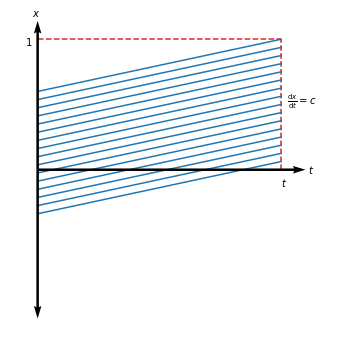

In [8]:
if (locs == []):
    t_f = 0.4
    t = np.linspace(0, t_f, num = nh_min + 1)
    vecs = [[0, 0, 0, 1], [0, 0, 0, -1], [0, 0, 1.8, 0]]
    X, Y, DX, DY = zip(*vecs)
    fig, ax = plt.subplots(figsize = [6, 6])
    plt.xlim(-0.05, 0.5)
    plt.ylim(-1.25, 1.25)
    
    ax.quiver(X, Y, DX, DY, color = 'k', scale = 2.25, zorder = 2)#, arrow_length_ratio = 0.075)
    for x_f in (xNode[::16]):
        x_1 = x_f - (cs[0] * t_f)
        x_c1 = (cs[0] * t) + x_1
        x = np.asarray(x_c1)
        if (x[-1] > 0):
            plt.plot(t, x, color = PT.ColorDefault(0), zorder = 1)
            # plt.text(1.01 * t_f, x[-1], r'$x$')
            print(x[-1])
    t_s = np.asarray([0, t_f])
    x_top = np.ones(2, float)
    t_fl = t_f * np.ones(2, float)
    x_tf = np.asarray([0, 1])
    
    plt.plot(t_s, x_top, color = PT.ColorDefault(3), linestyle = '--', zorder = 0)
    plt.plot(t_fl, x_tf, color = PT.ColorDefault(3), linestyle = '--', zorder = 0)
    plt.text(-0.02, 0.95, '1')#, color = PT.ColorDefault(3))
    plt.text(t_f, -0.125, r'$t$')#, color = PT.ColorDefault(3))
    plt.text(0.41, 0.5, r'$\frac{\mathrm{d} x}{\mathrm{d} t} = c$')
    plt.text(1.11 * t_f, -0.025, r'$t$')
    plt.text(-0.01, 1.175, r'$x$')
    plt.axis('off')
    plt.show()
    saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/SingMedCharLines' # + appendage
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = transparent)
    

[20, 43, 64, 85, 107]


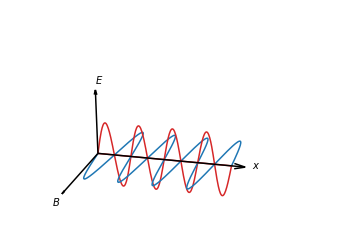

In [9]:
if (locs == []):
    vecs = [0, 0, 1]
    args = [sigma, mu]
    
    vecs = np.array([[0, 0, 0, 1.1, 0, 0], [0, 0, 0, 0, -0.2, 0], [0, 0, 0, 0, 0, 0.5]])
    X, Y, Z, DX, DY, DZ = zip(*vecs)
    
    #waveInit = WFT.InitCond(omega, physics, WFT.Gauss, args)#, cellAve = False)
    t = np.zeros(nh_min + 1)
    js = [((nh_min / 4) - 2) / 3, ((nh_min / 2) + 1) / 3, nh_min / 4, (nh_min - 1) / 3, (((5 * nh_min) / 4) + 2) / 3]# nh_min / 2]#, ((2 * nh_min) + 1) / 3]#, (((5 * nh_min) / 2) + 2) / 3]
    js = [int(j) for j in js]
    print(js)
    # fig, ax = plt.subplots()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection = '3d')
    ax.view_init(30, 285)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$t$')
    ax.set_zlabel(r'$u$')
    ax.axis('off')
    ax.quiver(X, Y, Z, DX, DY, DZ, color = 'k', arrow_length_ratio = 0.075)
    ax.text(1.15, 0, 0, r'$x$')
    ax.text(0, -0.25, 0, r'$B$')
    ax.text(0, 0, 0.55, r'$E$')
    ax.set_xlim(-0.1, 1.2)
    ax.set_ylim(-0.1, 0.21)
    ax.set_zlim(-0.1, 0.7)
    
    E = 0.25 * WT.MakeNodeWaves(omega)[:, 7] # WFT.InitCond(omega, physics, WFT.Gauss, args, t_val, cellAve = False, field = 'E')
    E1 = E + 0
    E1[E1 < 0] = 0
    E1 = np.ma.masked_invalid(E1, 0)
    E2 = E - E1
    B = -0.5 * E
    zero = 0 * E
    
    ax.plot(xNode, zero, E1, color = PT.ColorDefault(3), zorder = 1)
    ax.plot(xNode, zero, E2, color = PT.ColorDefault(3), zorder = 0)
    ax.plot(xNode, B, zero, color = PT.ColorDefault(0), zorder = 0)#, zorder = 1)
    
#     ax.plot(xs[:, i], ts[:, i], us[:, i], color = PT.ColorDefault(3), zorder = i)
    plt.show()
    saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/EMField' # + appendage
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
    

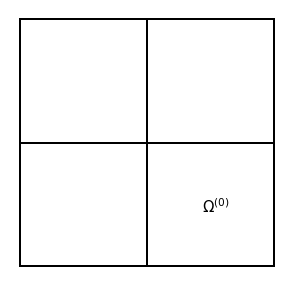

In [10]:
savePath = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/'
numPoints = 17
x = linspace(0, 1, num = numPoints)
y = np.ones(numPoints)
offset = 0.03125
bigness = 5
lw = 2


# plt.rcParams['axes.linewidth'] = lw # set the value globally

fig, ax = plt.subplots(figsize = (bigness, bigness))
ax = plt.plot(x, 0 * x, color = 'k', linewidth = lw)
ax = plt.plot(0 * x, x, color = 'k', linewidth = lw)
ax = plt.plot(x, y, color = 'k', linewidth = lw)
ax = plt.plot(y, x, color = 'k', linewidth = lw)

ax = plt.plot(x, 0.5 * y, color = 'k', linewidth = lw)
ax = plt.plot(0.5 * y, x, color = 'k', linewidth = lw)
plt.text(0.75 - offset, 0.25 - offset, r'$\Omega^{(0)}$', fontsize = 15)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
plt.tick_params(axis = 'y', which = 'both', left = False, right = False, labelleft = False)
figName = 'AMR1'
plt.axis('off')
plt.show()
fig.savefig(savePath + figName + '.png', bbox_inches = 'tight', dpi = 300, transparent = True)




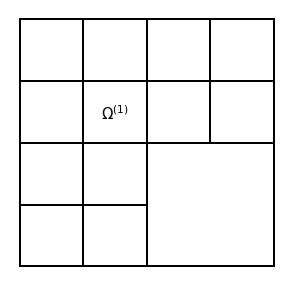

In [11]:
fig, ax = plt.subplots(figsize = (bigness, bigness))
ax = plt.plot(x, 0 * x, color = 'k', linewidth = lw)
ax = plt.plot(0 * x, x, color = 'k', linewidth = lw)
ax = plt.plot(x, y, color = 'k', linewidth = lw)
ax = plt.plot(y, x, color = 'k', linewidth = lw)

ax = plt.plot(x, 0.5 * y, color = 'k', linewidth = lw)
ax = plt.plot(0.5 * y, x, color = 'k', linewidth = lw)

ax = plt.plot(x, (0.25 * y) + 0.5, color = 'k', linewidth = lw)
ax = plt.plot(0.25 * y, x, color = 'k', linewidth = lw)
ax = plt.plot(0.75 * y, (0.5 * x) + 0.5, color = 'k', linewidth = lw)
plt.plot(0.5 * x, 0.25 * y, color = 'k', linewidth = lw)

plt.text(0.35 - offset, 0.625 - offset, r'$\Omega^{(1)}$', fontsize = 15)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
plt.tick_params(axis = 'y', which = 'both', left = False, right = False, labelleft = False)
figName = 'AMR2'
plt.axis('off')
plt.show()


fig.savefig(savePath + figName + '.png', bbox_inches = 'tight', dpi = 300, transparent = True)



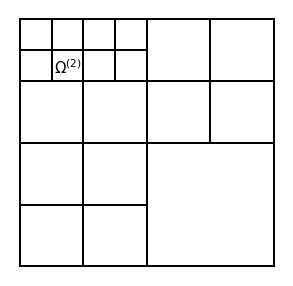

In [12]:
fig, ax = plt.subplots(figsize = (bigness, bigness))
ax = plt.plot(x, 0 * x, color = 'k', linewidth = lw)
ax = plt.plot(0 * x, x, color = 'k', linewidth = lw)
ax = plt.plot(x, y, color = 'k', linewidth = lw)
ax = plt.plot(y, x, color = 'k', linewidth = lw)

ax = plt.plot(x, 0.5 * y, color = 'k', linewidth = lw)
ax = plt.plot(0.5 * y, x, color = 'k', linewidth = lw)

ax = plt.plot(x, (0.25 * y) + 0.5, color = 'k', linewidth = lw)
ax = plt.plot(0.25 * y, x, color = 'k', linewidth = lw)
ax = plt.plot(0.75 * y, (0.5 * x) + 0.5, color = 'k', linewidth = lw)
ax = plt.plot(0.5 * x, 0.25 * y, color = 'k', linewidth = lw)

ax = plt.plot(0.5 * x, (0.125 * y) + 0.75, color = 'k', linewidth = lw)
ax = plt.plot((0.125 * y), (0.25 * x) + 0.75, color = 'k', linewidth = lw)
ax = plt.plot((0.125 * y) + 0.25, (0.25 * x) + 0.75, color = 'k', linewidth = lw)

plt.text(0.165 - offset, 0.8125 - offset, r'$\Omega^{(2)}$', fontsize = 15)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
plt.tick_params(axis = 'y', which = 'both', left = False, right = False, labelleft = False)
figName = 'AMR3'
plt.axis('off')
plt.show()

fig.savefig(savePath + figName + '.png', bbox_inches = 'tight', dpi = 300, transparent = True)



In [13]:
nh_min = 4
refRatio = 2

cells = list(np.arange(2))

In [14]:


omega = BT.Grid(nh_min)
omega.AddPatch(refRatio, cells)

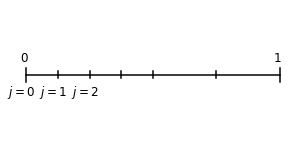

In [15]:
PT.PlotGrid(omega)
